# 1. Importação de bibliotecas


In [1]:
import zipfile
import os
import pandas as pd
import time
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)
from sklearn.ensemble import RandomForestRegressor

# 2. Download e carregamento dos dados

In [2]:
files.upload() #kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d ashyou09/global-data-center-and-ai-waterelectricity-usage

zip_name = "global-data-center-and-ai-waterelectricity-usage.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall(extract_path)

print("Arquivos extraídos:")
for f in os.listdir(extract_path):
    print(f)

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/ashyou09/global-data-center-and-ai-waterelectricity-usage
License(s): apache-2.0
100% 2.88M/2.88M [00:00<00:00, 50.9MB/s]

Arquivos extraídos:
data_center_hybrid.csv


# 3. Análise exploratória

In [3]:
df = pd.read_csv("/content/dataset/data_center_hybrid.csv")

print(df.shape)

(126770, 14)


In [4]:
df.head()

,Year,Facility_ID,Facility_Name,Owner_Company,City,Country,Facility_Type,Estimated_Capacity_MW,PUE,Cooling_System_Type,WUE_L_per_kWh,Daily_Electricity_Usage_MWh,Daily_Water_Usage_Gallons,Surrounding_Water_Stress_Tier
0,2019,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.24,1.975,Evaporative,1.481,183.62,36362.94,Low
1,2020,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.36,1.967,Evaporative,1.459,254.34,49833.60,Low
2,2021,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.47,1.928,Evaporative,1.450,266.85,53026.35,Low
3,2022,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.59,1.897,Evaporative,1.413,199.14,39198.30,Low
4,2023,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.70,1.869,Evaporative,1.389,225.94,44366.48,Low


In [5]:
df.columns

Index(['Year', 'Facility_ID', 'Facility_Name', 'Owner_Company', 'City',
       'Country', 'Facility_Type', 'Estimated_Capacity_MW', 'PUE',
       'Cooling_System_Type', 'WUE_L_per_kWh', 'Daily_Electricity_Usage_MWh',
       'Daily_Water_Usage_Gallons', 'Surrounding_Water_Stress_Tier'],
      dtype='object')

## 3.1. Remoção de colunas irrelevantes

In [6]:
X = df.drop(['Daily_Water_Usage_Gallons', 'Facility_ID', 'Facility_Name', 'Owner_Company', 'City'], axis=1)

y = df['Daily_Water_Usage_Gallons']

In [7]:
X.columns

Index(['Year', 'Country', 'Facility_Type', 'Estimated_Capacity_MW', 'PUE',
       'Cooling_System_Type', 'WUE_L_per_kWh', 'Daily_Electricity_Usage_MWh',
       'Surrounding_Water_Stress_Tier'],
      dtype='object')

In [8]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126770 entries, 0 to 126769
Data columns (total 9 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Year                           126770 non-null  int64  
 1   Country                        126770 non-null  object 
 2   Facility_Type                  126770 non-null  object 
 3   Estimated_Capacity_MW          126770 non-null  float64
 4   PUE                            126770 non-null  float64
 5   Cooling_System_Type            126770 non-null  object 
 6   WUE_L_per_kWh                  126770 non-null  float64
 7   Daily_Electricity_Usage_MWh    126770 non-null  float64
 8   Surrounding_Water_Stress_Tier  126770 non-null  object 
dtypes: float64(4), int64(1), object(4)
memory usage: 8.7+ MB


In [9]:
X.describe()

,Year,Estimated_Capacity_MW,PUE,WUE_L_per_kWh,Daily_Electricity_Usage_MWh
count,126770.000000,126770.000000,126770.000000,126770.000000,126770.000000
mean,2022.000000,23.075117,1.637746,0.820596,605.222368
std,2.000008,45.847195,0.190833,0.925481,1040.061940
min,2019.000000,1.000000,1.057000,0.001000,22.190000
25%,2020.000000,5.450000,1.518000,0.139000,167.432500
50%,2022.000000,9.870000,1.643000,0.232000,302.750000
75%,2024.000000,14.180000,1.787000,1.654000,451.370000
max,2025.000000,562.890000,2.000000,3.000000,14812.660000


In [10]:
X.isnull().sum()

,0
Year,0
Country,0
Facility_Type,0
Estimated_Capacity_MW,0
PUE,0
Cooling_System_Type,0
WUE_L_per_kWh,0
Daily_Electricity_Usage_MWh,0
Surrounding_Water_Stress_Tier,0


# 4. Pré-processamento


In [11]:
#machine learning não aceita texto diretamente
X = pd.get_dummies(X, columns=['Facility_Type', 'Cooling_System_Type', 'Country', 'Surrounding_Water_Stress_Tier'])

# 5. Separa dados para treino, teste e validação

In [12]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.1765, random_state=42)

print(f"Treino: {len(X_train)} porcentagem ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validação: {len(X_val)} porcentagem ({len(X_val)/len(X)*100:.1f}%)")
print(f"Teste: {len(X_test)} porcentagem ({len(X_test)/len(X)*100:.1f}%)")

Treino: 88735 porcentagem (70.0%)
Validação: 19019 porcentagem (15.0%)
Teste: 19016 porcentagem (15.0%)


# 6. Regressão linear

## 6.1. Treinamento

In [13]:
modelo_lr = LinearRegression()

inicio_treino_lr = time.time()

modelo_lr.fit(X_train, y_train)

fim_treino_lr = time.time()

tempo_treino_lr = fim_treino_lr - inicio_treino_lr

print(f"Tempo de treinamento: {tempo_treino_lr:.4f} segundos")

Tempo de treinamento: 6.0374 segundos


## 6.2. Avaliação

In [14]:
inicio_predicao_lr = time.time()

y_pred_val_lr = modelo_lr.predict(X_val)

fim_predicao_lr = time.time()

tempo_pred_lr = fim_predicao_lr - inicio_predicao_lr

print(f"Tempo de predição: {tempo_pred_lr:.4f} segundos")

Tempo de predição: 0.0518 segundos


In [15]:
mae_lr = mean_absolute_error(y_val, y_pred_val_lr)

rmse_lr = mean_squared_error(y_val, y_pred_val_lr) ** 0.5

r2_lr = r2_score(y_val, y_pred_val_lr)

In [16]:
print("REGRESSÃO LINEAR")
print(f"  MAE: {mae_lr:.2f}")
print(f"  RMSE: {rmse_lr:.2f}")
print(f"  R²: {r2_lr:.4f}")

REGRESSÃO LINEAR
  MAE: 90846.88
  RMSE: 195627.83
  R²: 0.7612


### 6.2.1. Gráficos

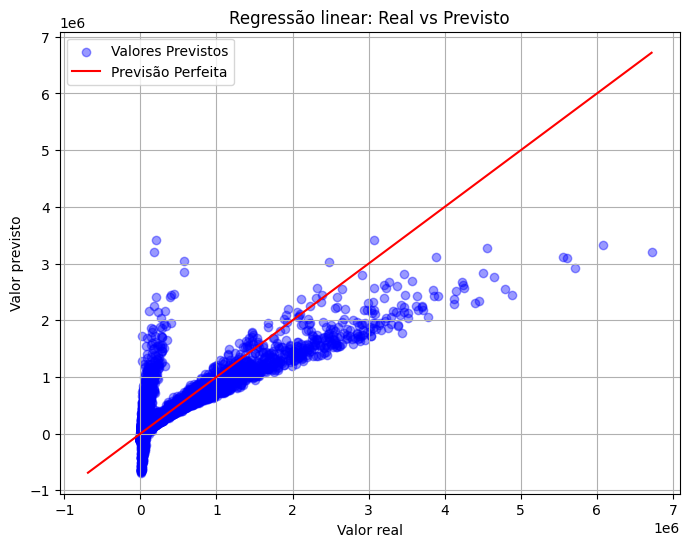

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(y_val, y_pred_val_lr, alpha=0.4, color='blue', label='Valores Previstos')

min_val = min(y_val.min(), y_pred_val_lr.min())
max_val = max(y_val.max(), y_pred_val_lr.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', label='Previsão Perfeita')

plt.xlabel("Valor real")
plt.ylabel("Valor previsto")

plt.title("Regressão linear: Real vs Previsto")
plt.legend()
plt.grid(True)
plt.show()

# 7. Random Forest


## 7.1 Treinamento e avaliação

In [18]:
resultados = []

for n in [10, 50, 100, 150]:
  modelo_rf = RandomForestRegressor(n_estimators = n)

  inicio_treino_rf = time.time()

  modelo_rf.fit(X_train, y_train)

  fim_treino_rf = time.time()

  tempo_treino_rf = fim_treino_rf - inicio_treino_rf

  #avaliacao
  inicio_predicao_rf = time.time()

  y_pred_val_rf = modelo_rf.predict(X_val)

  fim_predicao_rf = time.time()

  tempo_pred_rf = fim_predicao_rf - inicio_predicao_rf

  mae_rf = mean_absolute_error(y_val, y_pred_val_rf)

  rmse_rf = mean_squared_error(y_val, y_pred_val_rf) ** 0.5

  r2_rf = r2_score(y_val, y_pred_val_rf)

  resultados.append([n, tempo_treino_rf, tempo_pred_rf, mae_rf, rmse_rf, r2_rf])

### 7.1.1. Resultados

In [19]:
pd.DataFrame(resultados, columns=['n_estimators', 'tempo_treino', 'tempo_pred', 'mae_rf', 'rmse_rf', 'r2_rf'])

,n_estimators,tempo_treino,tempo_pred,mae_rf,rmse_rf,r2_rf
0,10,17.268234,0.101426,3202.056318,17204.663401,0.998153
1,50,86.740745,0.410760,2750.223537,16620.115525,0.998276
2,100,175.710208,0.816652,2687.018430,16601.401140,0.998280
3,150,263.666411,1.289386,2670.527108,16328.869072,0.998336


#### 7.1.1.1. Gráfico


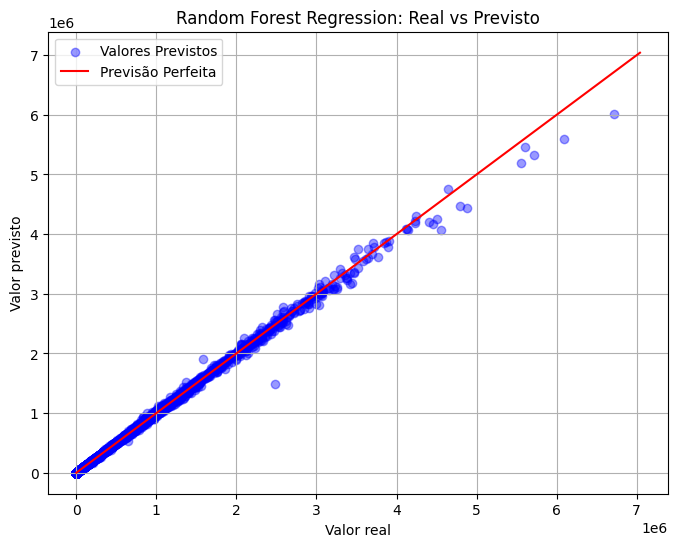

In [20]:
plt.figure(figsize=(8,6))

plt.scatter(y_val, y_pred_val_rf, alpha=0.4, color='blue', label='Valores Previstos')

min_val = min(y_test.min(), y_pred_val_rf.min())
max_val = max(y_test.max(), y_pred_val_rf.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', label='Previsão Perfeita')

plt.xlabel("Valor real")
plt.ylabel("Valor previsto")

plt.title("Random Forest Regression: Real vs Previsto")
plt.legend()
plt.grid(True)
plt.show()

#### 7.1.1.2. Cálculo de importâncias

In [21]:
importancias = modelo_rf.feature_importances_

df_importancias = pd.DataFrame({
    'Variavel': X.columns,
    'Importancia': importancias
})

df_importancias = df_importancias.sort_values(by='Importancia', ascending=False)

df_importancias.head(5)

,Variavel,Importancia
1,Estimated_Capacity_MW,0.477642
3,WUE_L_per_kWh,0.298863
4,Daily_Electricity_Usage_MWh,0.209227
9,Cooling_System_Type_Evaporative,0.011050
2,PUE,0.002759


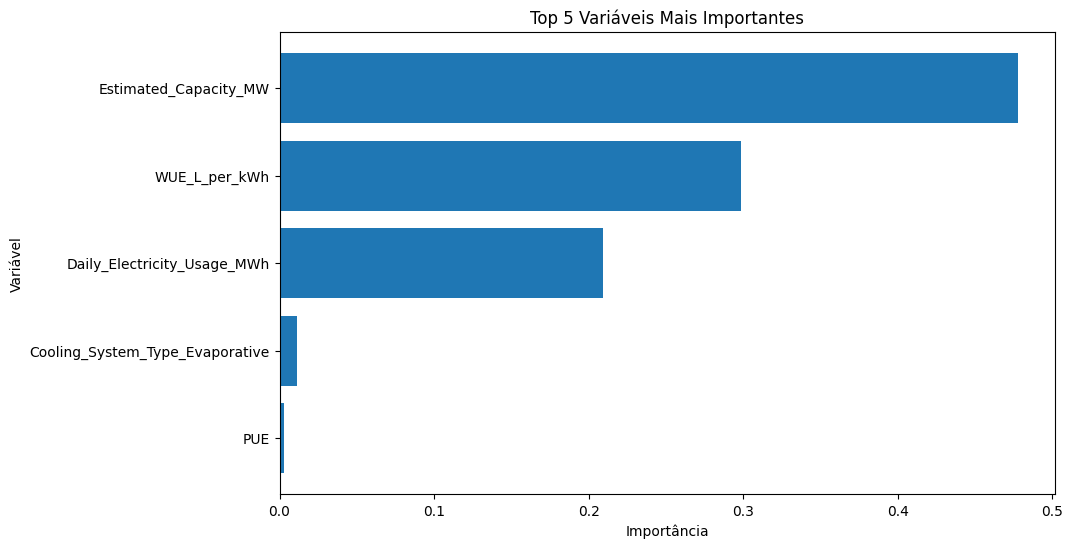

In [22]:
top5 = df_importancias.head(5)

plt.figure(figsize=(10,6))

plt.barh(
    top5['Variavel'],
    top5['Importancia']
)

plt.xlabel('Importância')
plt.ylabel('Variável')
plt.title('Top 5 Variáveis Mais Importantes')

plt.gca().invert_yaxis()

plt.show()

# 8. Comparação entre LR e RF

## 8.1. Tabela de métricas

In [23]:
comparacao = pd.DataFrame({
    'Modelo': [
        'Regressão Linear',
        'Random Forest'
    ],
    'MAE': [
        mae_lr,
        mae_rf
    ],
    'RMSE': [
        rmse_lr,
        rmse_rf
    ],
    'R²': [
        r2_lr,
        r2_rf
    ],
    'Tempo de treino (s)': [
        tempo_treino_lr,
        tempo_treino_rf
    ],
    'Tempo de predição (s)': [
        tempo_pred_lr,
        tempo_pred_rf
    ]
})

comparacao

,Modelo,MAE,RMSE,R²,Tempo de treino (s),Tempo de predição (s)
0,Regressão Linear,90846.883504,195627.827275,0.761184,6.037448,0.051756
1,Random Forest,2670.527108,16328.869072,0.998336,263.666411,1.289386


## 8.2. Gráfico de barras da métrica R²

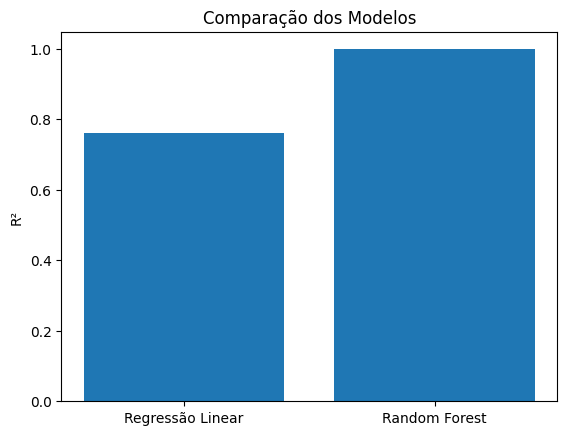

In [24]:
plt.bar(
    comparacao['Modelo'],
    comparacao['R²']
)

plt.ylabel("R²")
plt.title("Comparação dos Modelos")
plt.show()